<a href="https://colab.research.google.com/github/wooj-choi/teaching_IC_2026sp/blob/main/Profit_maximization_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Profit Maximization of a Competitive Firm
### A Numerical Example

---

This notebook works through a **complete numerical example** of profit maximization under perfect competition.

**Structure:**
1. Specify functional forms for market demand, market supply, and firm costs
2. Solve for the competitive equilibrium price P*
3. Derive and plot the firm's cost curves: TC, MC, AC, AVC
4. Plot the dual diagram — Market (left) and Individual Firm (right)
5. Identify Q* where MR = MC, compute and shade the profit rectangle


## 1. Setup — Imports

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import brentq

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 110,
})

---
## 2. Market Demand and Supply — Functional Forms

**Market Demand** (inverse demand):
$$P^D = 100 - 0.5\,Q_D$$

**Market Supply** (aggregated from firms' MC curves):
$$P^S = 4 + 0.3\,Q_S$$

**Equilibrium** condition: $P^D = P^S$ → solve for $Q^*$ and $P^*$.

$$100 - 0.5Q = 4 + 0.3Q \implies Q^* = \frac{96}{0.8} = 120, \quad P^* = 40$$

[//]: # (Q=62.56 <- atc minimum)
[//]: # (ATC=MC=13.6362.56 <- corresponding price)
[//]: # (c=-38.1883 <- corresponding c)

In [77]:
# ── Market demand and supply ──────────────────────────────────────────────────
# Inverse demand:  P = a - b*Q


a, b = 100, 0.5
demand_P = lambda Q: a - b * Q          # P as function of Q
demand_Q = lambda P: (a - P) / b        # Q as function of P

# Inverse supply:  P = c + s*Q
c, s = 4, 0.3
supply_P = lambda Q: c + s * Q
supply_Q = lambda P: (P - c) / s

# Equilibrium: a - b*Q = c + s*Q  →  Q* = (a-c)/(b+s)
Q_star = (a - c) / (b + s)
P_star = demand_P(Q_star)               # = supply_P(Q_star)

print("═" * 40)
print(" MARKET EQUILIBRIUM")
print("═" * 40)
print(f"  Demand :  P = {a} - {b}·Q")
print(f"  Supply :  P = {c} + {s}·Q")
print(f"  Q*     =  {Q_star:.1f}  units")
print(f"  P*     =  ${P_star:.2f} per unit")
print("═" * 40)

════════════════════════════════════════
 MARKET EQUILIBRIUM
════════════════════════════════════════
  Demand :  P = 100 - 0.5·Q
  Supply :  P = 4 + 0.3·Q
  Q*     =  120.0  units
  P*     =  $40.00 per unit
════════════════════════════════════════


---
## 3. Firm-Level Cost Functions

The representative firm has a **cubic total cost function**:

**Cost**

$$\begin{align}
TC(q)  &= TVC + FC=0.005\,q^3 - 0.6\,q^2 + 30\,q + 100 \\
TVC(q) &= 0.005\,q^3 - 0.6\,q^2 + 30\,q \\
FC     &= 100 \\
MC(q)  &= 0.015\,q^2 - 1.2\,q + 30 \\
ATC(q) &= \frac{TC}{q} = 0.005\,q^2 - 0.6\,q + 30 + \frac{100}{q}\\
AVC(q) &= \frac{TVC}{q} = 0.005\,q^2 - 0.6\,q + 30 \\
AFC(q) &= \frac{FC}{q}=\frac{100}{q}
\end{align}$$

**Profit:**

$$\begin{align}\pi(q) &= TR(Q)-TC(Q)\\
&=\color{red}{P^*} \cdot q - TC(q)\end{align}$$

**Profit-maximizing condition:** $MR = MC$


$$ \begin{align}
P^* &= MC(q^*) \\
\color{red}{40} &= 0.015q^2 - 1.2q + 30 \\
 0 &=0.015q^2 - 1.2q - 10  \end{align}$$

In [78]:
# ── Firm cost functions ───────────────────────────────────────────────────────
alpha, beta, gamma, FC = 0.005, 0.6, 30, 100

TC  = lambda q: alpha*q**3 - beta*q**2 + gamma*q + FC
TVC = lambda q: alpha*q**3 - beta*q**2 + gamma*q
MC  = lambda q: 3*alpha*q**2 - 2*beta*q + gamma
ATC = lambda q: TC(q) / q
AVC = lambda q: TVC(q) / q
AFC = lambda q: FC / q
Pi  = lambda q: P_star * q - TC(q)

# Profit-max: MR = P* = MC(q)  →  find q where MC(q) - P* = 0 (on rising branch)
# MC is U-shaped; minimum at q = beta/(3*alpha) = 0.6/0.015 = 40
q_min_mc = beta / (3 * alpha)   # MC minimum
q_firm = brentq(lambda q: MC(q) - P_star, q_min_mc, 200)

atc_at_q  = ATC(q_firm)
avc_at_q  = AVC(q_firm)
profit     = Pi(q_firm)

print("═" * 48)
print(" FIRM COST STRUCTURE")
print("═" * 48)
print(f"  TC(q)  =  {alpha}q³ - {beta}q² + {gamma}q + {FC}")
print(f"  MC(q)  =  {3*alpha}q² - {2*beta}q + {gamma}")
print(f"  ATC(q) =  TC(q) / q")
print(f"  AVC(q) =  {alpha}q² - {beta}q + {gamma}")
print(f"  AFC(q) =  {FC} / q")
print("─" * 48)
print(" FIRM OPTIMUM  (MR = MC = P*)")
print("─" * 48)
print(f"  Firm output  q*    =  {q_firm:.2f} units")
print(f"  Price        P*    =  ${P_star:.2f}")
print(f"  MR           MR    =  ${P_star:.2f}   [= P* for price-taker]")
print(f"  MC at q*           =  ${MC(q_firm):.2f}")
print(f"  ATC at q*          =  ${atc_at_q:.2f}")
print(f"  AVC at q*          =  ${avc_at_q:.2f}")
print(f"  TC at q*           =  ${TC(q_firm):.2f}")
print(f"  Profit  π          =  ${profit:.2f}")
print("═" * 48)

════════════════════════════════════════════════
 FIRM COST STRUCTURE
════════════════════════════════════════════════
  TC(q)  =  0.005q³ - 0.6q² + 30q + 100
  MC(q)  =  0.015q² - 1.2q + 30
  ATC(q) =  TC(q) / q
  AVC(q) =  0.005q² - 0.6q + 30
  AFC(q) =  100 / q
────────────────────────────────────────────────
 FIRM OPTIMUM  (MR = MC = P*)
────────────────────────────────────────────────
  Firm output  q*    =  87.61 units
  Price        P*    =  $40.00
  MR           MR    =  $40.00   [= P* for price-taker]
  MC at q*           =  $40.00
  ATC at q*          =  $16.95
  AVC at q*          =  $15.81
  TC at q*           =  $1485.23
  Profit  π          =  $2019.15
════════════════════════════════════════════════


---
## 4. Cost Schedule Table

In [79]:
# ── Cost schedule at selected output levels ───────────────────────────────────
qs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, round(q_firm)]
qs = sorted(set(qs))

header = f"{'q':>6} {'TC':>8} {'TVC':>8} {'FC':>6} {'MC':>8} {'ATC':>8} {'AVC':>8} {'AFC':>8} {'π':>10}"
print(header)
print("─" * len(header))
for q in qs:
    mark = " ◄ Q*" if q == round(q_firm) else ""
    print(f"{q:>6} {TC(q):>8.1f} {TVC(q):>8.1f} {FC:>6} "
          f"{MC(q):>8.2f} {ATC(q):>8.2f} {AVC(q):>8.2f} {AFC(q):>8.2f} {Pi(q):>10.2f}{mark}")

     q       TC      TVC     FC       MC      ATC      AVC      AFC          π
──────────────────────────────────────────────────────────────────────────────
    10    345.0    245.0    100    19.50    34.50    24.50    10.00      55.00
    20    500.0    400.0    100    12.00    25.00    20.00     5.00     300.00
    30    595.0    495.0    100     7.50    19.83    16.50     3.33     605.00
    40    660.0    560.0    100     6.00    16.50    14.00     2.50     940.00
    50    725.0    625.0    100     7.50    14.50    12.50     2.00    1275.00
    60    820.0    720.0    100    12.00    13.67    12.00     1.67    1580.00
    70    975.0    875.0    100    19.50    13.93    12.50     1.43    1825.00
    80   1220.0   1120.0    100    30.00    15.25    14.00     1.25    1980.00
    88   1501.0   1401.0    100    40.56    17.06    15.92     1.14    2019.04 ◄ Q*
    90   1585.0   1485.0    100    43.50    17.61    16.50     1.11    2015.00
   100   2100.0   2000.0    100    60.00    21.

---
## 5. The Dual Diagram — Market (left) and Firm (right)

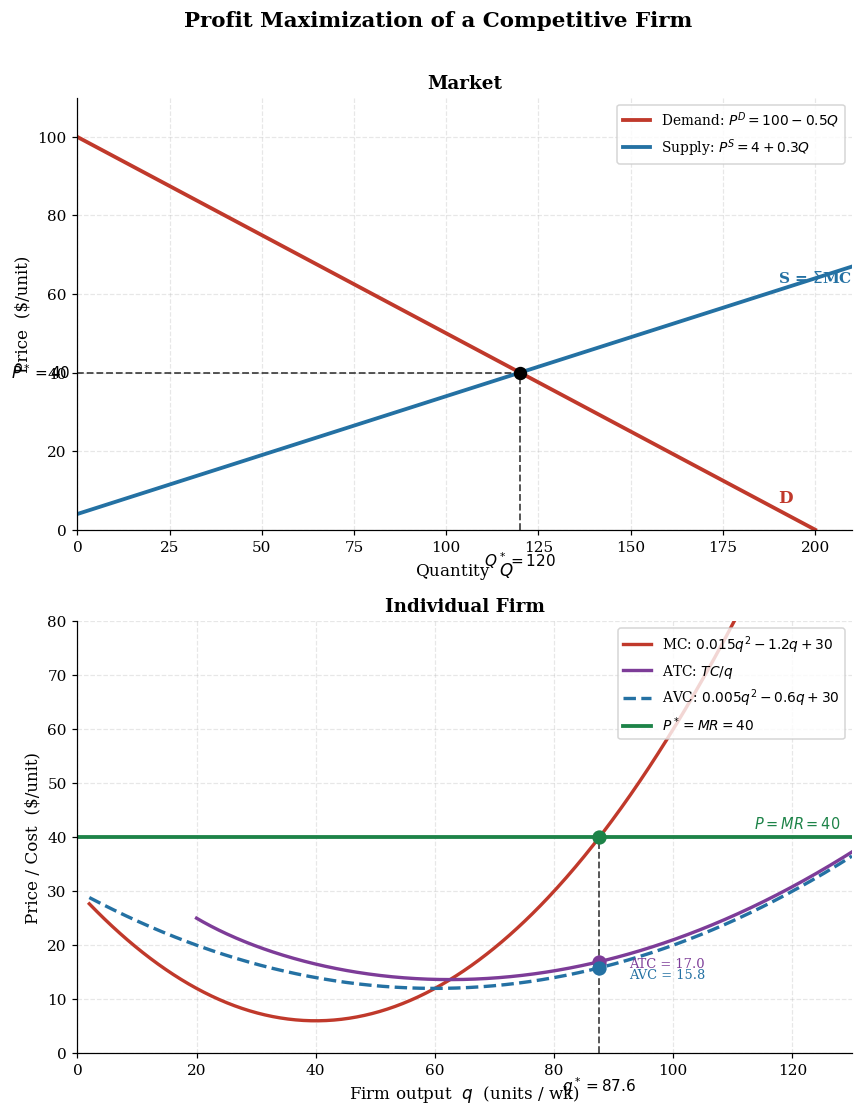

Figure saved as profit_maximization.png


In [80]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
fig.suptitle("Profit Maximization of a Competitive Firm", fontsize=14, fontweight='bold', y=1.01)

# ── LEFT: Market equilibrium ──────────────────────────────────────────────────
Q_mkt = np.linspace(0, 210, 400)

# Only plot where prices are positive
Qd = Q_mkt[demand_P(Q_mkt) >= 0]
Qs = Q_mkt[supply_P(Q_mkt) <= 110]

ax1.plot(Qd, demand_P(Qd), color='#C0392B', lw=2.5, label=r'Demand: $P^D = 100 - 0.5Q$')
ax1.plot(Qs, supply_P(Qs), color='#2471A3', lw=2.5, label=r'Supply: $P^S = 4 + 0.3Q$')

# Equilibrium dashes
ax1.plot([0, Q_star], [P_star, P_star], 'k--', lw=1.2, alpha=0.7)
ax1.plot([Q_star, Q_star], [0, P_star], 'k--', lw=1.2, alpha=0.7)
ax1.scatter([Q_star], [P_star], color='black', zorder=5, s=60)

# Labels
ax1.annotate(f'$P^* = {P_star:.0f}$', xy=(0, P_star), xytext=(-18, P_star),
             fontsize=10, va='center', annotation_clip=False)
ax1.annotate(f'$Q^* = {Q_star:.0f}$', xy=(Q_star, 0), xytext=(Q_star, -5),
             fontsize=10, ha='center', va='top')
ax1.text(190, demand_P(190)+2, 'D', fontsize=11, color='#C0392B', fontweight='bold')
ax1.text(190, supply_P(190)+2, r'S = $\Sigma$MC', fontsize=10, color='#2471A3', fontweight='bold')

ax1.set_xlabel('Quantity  $Q$', fontsize=11)
ax1.set_ylabel('Price  ($/unit)', fontsize=11)
ax1.set_title('Market', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 210)
ax1.set_ylim(0, 110)
ax1.legend(fontsize=9, loc='upper right')

# ── RIGHT: Firm ───────────────────────────────────────────────────────────────
q = np.linspace(2, 130, 500)

# Curves
q_atc = np.linspace(20, 130, 500)  # ATC starts from q=20
ax2.plot(q, MC(q),       color='#C0392B', lw=2.2, label=r'MC: $0.015q^2 - 1.2q + 30$')
ax2.plot(q_atc, ATC(q_atc), color='#7D3C98', lw=2.2, label=r'ATC: $TC/q$')
ax2.plot(q, AVC(q), color='#2471A3', lw=2.2, label=r'AVC: $0.005q^2 - 0.6q + 30$', linestyle='--')

# P* = MR line
ax2.axhline(P_star, color='#1D8348', lw=2.5, label=f'$P^* = MR = {P_star:.0f}$')
ax2.text(128, P_star + 1, f'$P = MR = {P_star:.0f}$', fontsize=9.5,
         color='#1D8348', ha='right', va='bottom')

# Dashed vertical at q_firm
ax2.plot([q_firm, q_firm], [0, P_star], 'k--', lw=1.2, alpha=0.7)

# Key points
ax2.scatter([q_firm], [P_star],    color='#1D8348', zorder=6, s=70)
ax2.scatter([q_firm], [atc_at_q],  color='#7D3C98', zorder=6, s=70)
ax2.scatter([q_firm], [avc_at_q],  color='#2471A3', zorder=6, s=70)

# Annotations
ax2.annotate(f'$q^* = {q_firm:.1f}$', xy=(q_firm, 0), xytext=(q_firm, -4),
             fontsize=10, ha='center', va='top')
ax2.annotate(f'ATC = {atc_at_q:.1f}', xy=(q_firm, atc_at_q),
             xytext=(q_firm + 5, atc_at_q - 1),
             fontsize=8.5, color='#7D3C98')
ax2.annotate(f'AVC = {avc_at_q:.1f}', xy=(q_firm, avc_at_q),
             xytext=(q_firm + 5, avc_at_q - 2),
             fontsize=8.5, color='#2471A3')

ax2.set_xlabel('Firm output  $q$  (units / wk)', fontsize=11)
ax2.set_ylabel('Price / Cost  ($/unit)', fontsize=11)
ax2.set_title('Individual Firm', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 130)
ax2.set_ylim(0, 80)
ax2.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('profit_maximization.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved as profit_maximization.png")

---
## 6. Total Cost (TC) and Total Revenue (TR) — Profit Visualised Directly

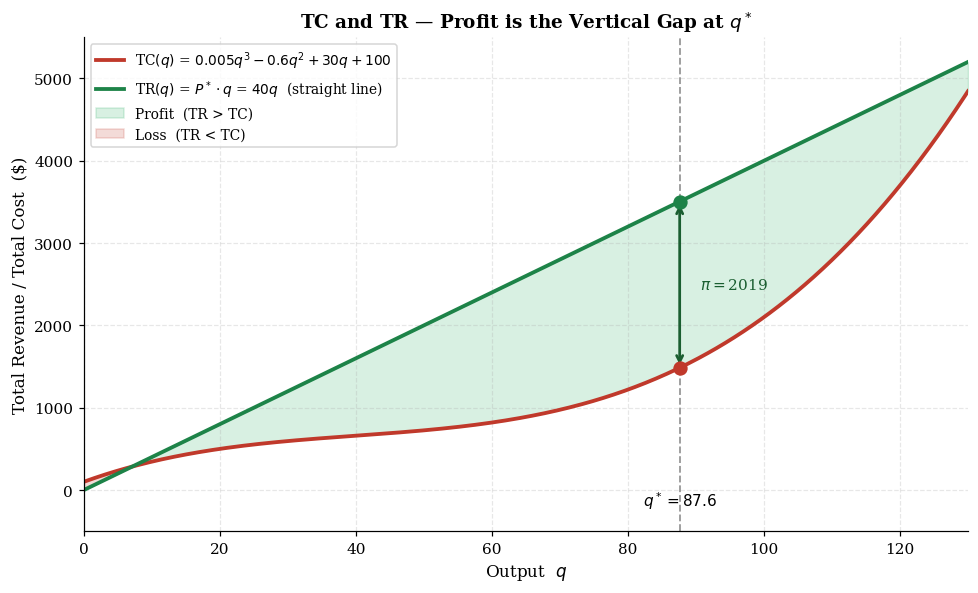

In [81]:
# ── TC vs TR plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

q_range = np.linspace(0, 130, 500)
TR = P_star * q_range

ax.plot(q_range, TC(q_range), color='#C0392B', lw=2.5,
        label=r'TC$(q)$ = $0.005q^3 - 0.6q^2 + 30q + 100$')
ax.plot(q_range, TR,           color='#1D8348', lw=2.5,
        label=f'TR$(q)$ = $P^* \\cdot q$ = $40q$  (straight line)')

# Shade profit/loss regions
ax.fill_between(q_range, TC(q_range), TR,
                where=(TR >= TC(q_range)), alpha=0.18, color='#27AE60', label='Profit  (TR > TC)')
ax.fill_between(q_range, TC(q_range), TR,
                where=(TR < TC(q_range)),  alpha=0.18, color='#C0392B', label='Loss  (TR < TC)')

# Vertical at q_firm
ax.axvline(q_firm, color='gray', lw=1.2, ls='--', alpha=0.8)
ax.scatter([q_firm], [TC(q_firm)], color='#C0392B', zorder=5, s=70)
ax.scatter([q_firm], [P_star * q_firm], color='#1D8348', zorder=5, s=70)

# Profit arrow
ax.annotate('', xy=(q_firm, P_star * q_firm), xytext=(q_firm, TC(q_firm)),
            arrowprops=dict(arrowstyle='<->', color='#1A5E30', lw=1.8))
ax.text(q_firm + 3, (P_star * q_firm + TC(q_firm)) / 2,
        f'$\\pi = ${profit:.0f}', fontsize=10, color='#1A5E30', va='center')
ax.text(q_firm, -200, f'$q^* = {q_firm:.1f}$', ha='center', fontsize=10)

ax.set_xlabel('Output  $q$', fontsize=11)
ax.set_ylabel('Total Revenue / Total Cost  ($)', fontsize=11)
ax.set_title('TC and TR — Profit is the Vertical Gap at $q^*$', fontsize=12, fontweight='bold')
ax.set_xlim(0, 130)
ax.set_ylim(-500, 5500)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tc_tr.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 7. Summary

| Item | Value |
|---|---|
| Market demand | $P = 100 - 0.5Q$ |
| Market supply | $P = 4 + 0.3Q$ |
| Equilibrium price | $P^* = \$40$ |
| Equilibrium quantity | $Q^* = 120$ |
| Firm's TC | $0.005q^3 - 0.6q^2 + 30q + 100$ |
| Firm's MC | $0.015q^2 - 1.2q + 30$ |
| Firm's ATC | $TC/q$ |
| Firm's AVC | $0.005q^2 - 0.6q + 30$ |
| Profit-max condition | $MR = MC \Rightarrow P^* = MC(q^*)$ |
| Firm output $q^*$ | solved numerically from $MC(q) = 40$ |
| Economic profit $\pi$ | $(P^* - ATC(q^*)) \times q^*$ |

**Long-run implication:** If $\pi > 0$, new firms enter → market supply shifts right → $P^*$ falls → profits erode until $P^* = ATC_{\min}$ (zero economic profit).